In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud
import re

In [4]:
tweet_df = pd.read_parquet("../data/dataset/stock_tweets.parquet")
tweet_df

,ticker,text,created_at,user_id,date
0,VZ,"gdp news "" actives on open ATUSER aapl tsl...",2014-10-14 13:39:49+00:00,1923902360,2014-10-14
1,VZ,rt ATUSER psw seeking alpha june trade review...,2015-06-20 14:18:10+00:00,3232889321,2015-06-20
2,VZ,rt ATUSER psw seeking alpha june trade review...,2015-06-20 16:16:05+00:00,3238685909,2015-06-20
3,VZ,rt ATUSER psw seeking alpha june trade review...,2015-06-20 16:25:57+00:00,2740607613,2015-06-20
4,VZ,rt ATUSER psw seeking alpha june trade review...,2015-06-20 16:01:01+00:00,3234872187,2015-06-20
...,...,...,...,...,...
106333,CODI,stock contest pick googl and win a free tab...,2014-09-07 00:20:34+00:00,386787305,2014-09-07
106334,CODI,codi compass diversified holdings wk low click...,2015-05-18 13:34:15+00:00,2579477766,2015-05-18
106335,CODI,codi compass diversified holdings files sec f...,2014-08-09 10:38:34+00:00,2717670854,2014-08-09
106336,CODI,codi compass diversified holdings financials U...,2015-06-01 19:34:12+00:00,2181403417,2015-06-01


In [9]:
stock_table_df = pd.read_csv("../data/stocknet-dataset/StockTable")
stock_table_df.to_parquet("../data/dataset/stock_table.parquet", index=False)

In [13]:
stock_table = pd.read_parquet("../data/dataset/stock_table.parquet")
stock_table

,Sector,Symbol,Company
0,Basic Matierials,XOM,Exxon Mobil Corporation
1,Basic Matierials,RDS-B,Royal Dutch Shell
2,Basic Matierials,PTR,PetroChina Company Limited
3,Basic Matierials,CVX,Chevron Corporation
4,Basic Matierials,TOT,TOTAL S.A.
...,...,...,...
83,Technology,ORCL,Oracle Corporation
84,Technology,TSM,Taiwan Semiconductor Manufacturing Company Lim...
85,Technology,VZ,Verizon Communications Inc.
86,Technology,INTC,Intel Corporation


In [15]:
stock_price = pd.read_parquet("../data/dataset/stock_prices.parquet")
stock_price

,Date,Open,High,Low,Close,Adj Close,Volume,Ticker
0,2012-09-04,18.990000,19.139999,18.799999,19.000000,16.202320,27006700.0,CSCO
1,2012-09-05,19.000000,19.120001,18.870001,18.900000,16.117046,30580300.0,CSCO
2,2012-09-06,19.070000,19.750000,19.049999,19.730000,16.824829,59444100.0,CSCO
3,2012-09-07,19.549999,19.650000,19.250000,19.559999,16.679861,44786600.0,CSCO
4,2012-09-10,19.430000,19.469999,19.100000,19.150000,16.330235,40047200.0,CSCO
...,...,...,...,...,...,...,...,...
108587,2017-08-28,39.610001,39.680000,39.299999,39.529999,39.529999,2119900.0,PPL
108588,2017-08-29,39.590000,39.650002,39.360001,39.380001,39.380001,1443900.0,PPL
108589,2017-08-30,39.270000,39.419998,39.110001,39.180000,39.180000,1825100.0,PPL
108590,2017-08-31,39.259998,39.320000,39.169998,39.240002,39.240002,2086200.0,PPL


In [16]:
#(2892, 3)

tweet_df.shape

(106338, 5)

In [17]:
merged_twitter_df = tweet_df.groupby(
    ["date", "ticker"], 
    as_index=False
).agg({
    "text": lambda x: " ".join(x)
})

In [18]:
merged_twitter_df

,date,ticker,text
0,2013-12-31,AAPL,rt ATUSER summary of yesterdays webcast featur...
1,2013-12-31,C,well done ucla wins won a bowl game beat c
2,2013-12-31,GOOG,rt ATUSER summary of yesterdays webcast featur...
3,2014-01-01,AAPL,rt ATUSER summary of yesterdays webcast featur...
4,2014-01-01,AMZN,apple screwed up big time URL amzn aapl
...,...,...,...
25653,2015-12-31,UNH,eum stock message board updated wednesday de...
25654,2015-12-31,UTX,anfi up pm on m contract URL upside pt...
25655,2015-12-31,V,v msft nke mcd hd ge dis URL best perf...
25656,2015-12-31,VZ,amazon has the fastestgrowing web properties i...


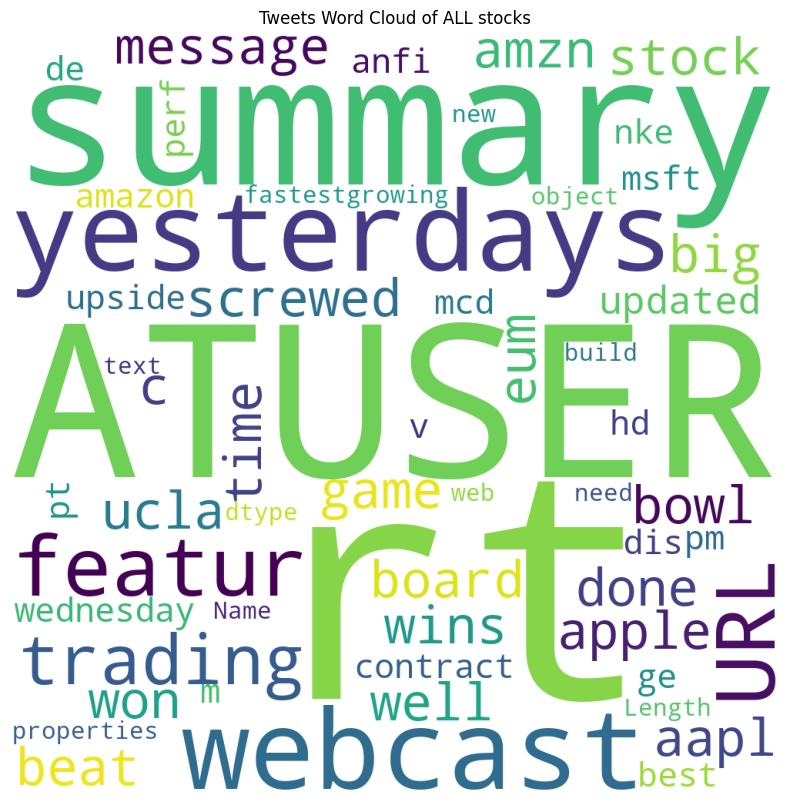

In [19]:
tweets_word_cloud = WordCloud(background_color = 'white', width = 1000, height = 1000).generate(str(merged_twitter_df['text']))
plt.figure(figsize=(10,10))
plt.imshow(tweets_word_cloud)
plt.axis('off')
plt.title('Tweets Word Cloud of ALL stocks')
plt.show()

In [22]:
for i in range(len(merged_twitter_df["text"])):
        more_patterns = re.compile(
    r'(\s*)({})(\s*)|(\s*)ATUSER(\s*)|(\s*)AT_USER(\s*)|(\s*)URL(\s*)|(\s*)rt(\s*)|(\s*)inc(\s*)|(\s*)ie(\s*)'
    .format(merged_twitter_df["ticker"][i]),
    flags=re.IGNORECASE
    )

        merged_twitter_df.loc[i, "text"] = more_patterns.sub('', merged_twitter_df.loc[i, "text"])

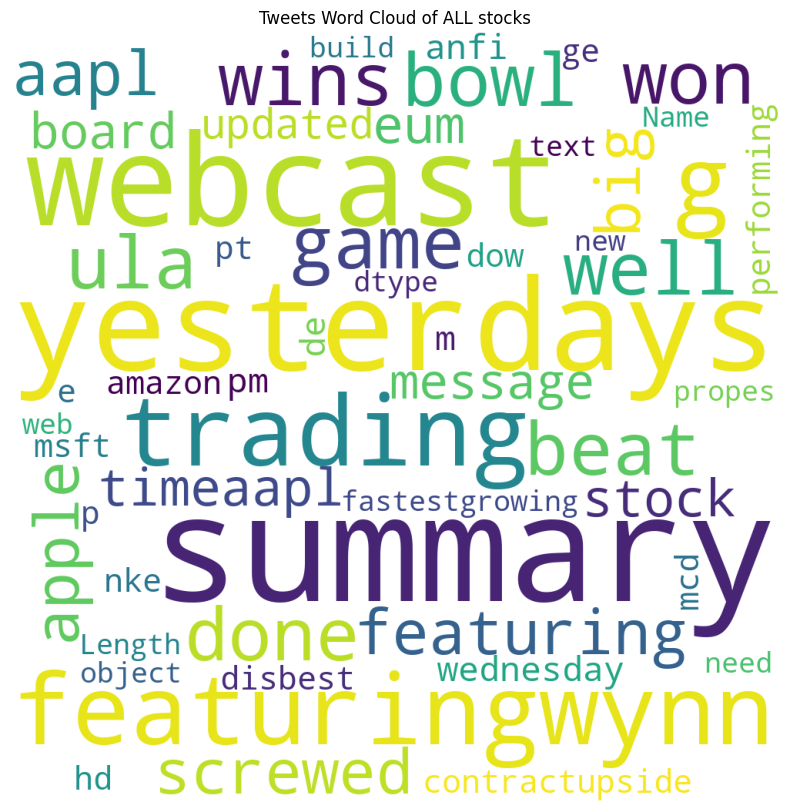

In [23]:
tweets_word_cloud = WordCloud(background_color = 'white', width = 1000, height = 1000).generate(str(merged_twitter_df['text']))
plt.figure(figsize=(10,10))
plt.imshow(tweets_word_cloud)
plt.axis('off')
plt.title('Tweets Word Cloud of ALL stocks')
plt.show()

In [25]:
merged_twitter_df.to_parquet("../data/dataset/merged_stock_tweet.parquet", index=False)